In [72]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [96]:
experiment_dir = Path("/Users/patrick/Experiments/misdro/normal_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])


# base_path = "/dcs/large/u1508153/misdro/normal_bayes_newsvendor"

# # load BDRO results and remember to filter (temporary hack for now)
# results_df = pd.read_csv(Path(base_path) / "results.csv", index_col=["uuid", "replication"])
# results_df = results_df.loc[results_df["algorithm"] == "kl_bdro"]

# for setting in ["10000", "10_10", "20_20", "30_30", "50_50"]:
#     experiment_dir = Path(base_path + "_" + setting)
#     assert experiment_dir.exists()
#     df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
#     results_df = pd.concat([results_df, df])

num_total_samples = []
for _, row in results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "our_kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"])
results_df["num_total_samples"] = num_total_samples

results_df

mean_cost    var_cost  \
uuid                                 replication                          
bddfc0a6-cc51-459f-a3e7-e3de26e16329 0            38.081225  945.352932   
                                     1            32.813612  802.330776   
                                     2            38.732984  941.853238   
                                     3            34.447986  761.715384   
                                     4            35.513364  524.249629   
...                                                     ...         ...   
6877dc5a-3e6e-4562-bbd6-4db6be323178 195          35.494315  569.388895   
                                     196          40.219034  393.644314   
                                     197          35.836101  697.886412   
                                     198          35.099532  345.762851   
                                     199          45.075313  529.324208   

                                                   solution  dgp_time  \
uuid                                 replication                        
bddfc0a6-cc51-459f-a3e7-e3de26e16329 0            29.665267  0.000252   
                                     1            29.325386  0.000395   
                                     2            29.954337  0.000520   
                                     3            33.151281  0.000476   
                                     4            34.057693  0.000376   
...                                                     ...       ...   
6877dc5a-3e6e-4562-bbd6-4db6be323178 195          21.718834  0.000686   
                                     196          23.202384  0.000602   
                                     197          24.203212  0.000597   
                                     198          22.081607  0.000580   
                                     199          28.206561  0.000711   

                                                  likelihood_time  \
uuid                                 replication                    
bddfc0a6-cc51-459f-a3e7-e3de26e16329 0                   0.000037   
                                     1                   0.000055   
                                     2                   0.000066   
                                     3                   0.000057   
                                     4                   0.000049   
...                                                           ...   
6877dc5a-3e6e-4562-bbd6-4db6be323178 195                 0.000119   
                                     196                 0.000118   
                                     197                 0.000114   
                                     198                 0.000119   
                                     199                 0.000119   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
bddfc0a6-cc51-459f-a3e7-e3de26e16329 0                  0.000094    0.019180   
                                     1                  0.000150    0.032937   
                                     2                  0.000175    0.032361   
                                     3                  0.000198    0.032336   
                                     4                  0.000133    0.030651   
...                                                          ...         ...   
6877dc5a-3e6e-4562-bbd6-4db6be323178 195                0.000240    0.165294   
                                     196                0.000245    0.157819   
                                     197                0.000248    0.149552   
                                     198                0.000236    0.160358   
                                     199                0.000236    0.127672   

                                                  setup_time    algorithm  \
uuid                                 replication                            
bddfc0a6-cc51-459f-a3e7-e3de26e

In [74]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                               mean   
algorithm   dgp              epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal           0.05    bayes     normal_gamma 10                    10                      38.238413   
                                                            20                    20                      38.050899   
                                                            30                    30                      37.899941   
                             0.06    bayes     normal_gamma 10                    10                      38.270103   
                                                            20                    20                      38.094924   
...                                                                                                             ...   
our_kl_bdro truncated_normal 2.50    bayes     normal_gamma 1                     400                     38.914522   
                                                                                  900                     39.755735   
                             3.00    bayes     normal_gamma 1                     100                     36.656960   
                                                                                  400                     39.404583   
                                                                                  900                     40.489439   

                                                                                                                     \
                                                                                                                var   
algorithm   dgp              epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal           0.05    bayes     normal_gamma 10                    10                      24.345279   
                                                            20                    20                      21.627086   
                                                            30                    30                      21.299101   
                             0.06    bayes     normal_gamma 10                    10                      24.399690   
                                                            20                    20                      21.703220   
...                                                                                                             ...   
our_kl_bdro truncated_normal 2.50    bayes     normal_gamma 1                     400                     54.882723   
                                                                                  900                     59.020025   
                             3.00    bayes     normal_gamma 1                     100                     45.783558   
                                                                                  400                     59.764760   
                                                                                  900                     65.130136   

                                                                                                            var_cost  \
                                                                                                                mean   
algorithm   dgp              epsilon inference posterior    num_posterior_samples num_likelihood_samples               
kl_bdro     normal           0.05    bayes     normal_gamma 10                    10                      797.693870   
                                                            20                    20                      771.852806   
                                                            30                    30                      770.553878   
                             0.06    bayes     norma

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_60161/2954010588.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


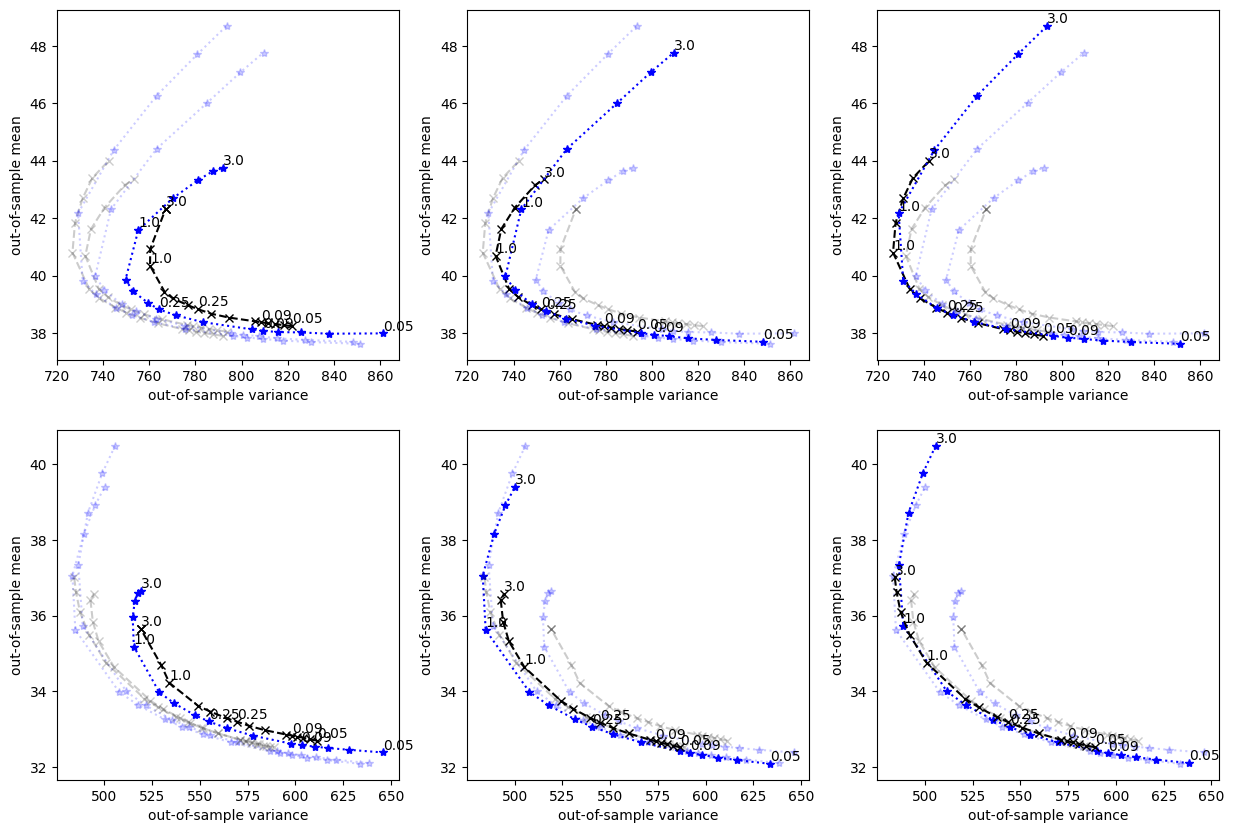

In [75]:
from mis_dro.plot import mean_variance_plot, algorithm_style

from enum import StrEnum

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

compare_col="algorithm"
gb_col="dgp"
ncols=2
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES_SQRT = [10, 20, 30]

nrows = 2
ncols = len(TOTAL_SAMPLES_SQRT)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5*ncols, nrows*5))

for j, n_total_samples_sqrt in enumerate(TOTAL_SAMPLES_SQRT):
    df = agg_df.loc[(
        (likelihood_sr == n_total_samples_sqrt) & (posterior_sr == n_total_samples_sqrt)
        | (likelihood_sr == n_total_samples_sqrt ** 2) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)
    for k in range(len(TOTAL_SAMPLES_SQRT)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                mean_variance_plot(axes[i, k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled)
            

fig.show()

## Solve time

In [104]:
results_df.groupby(["algorithm", "dgp", "num_total_samples"]).agg({"solve_time": ["mean", "var"]}).unstack(level="algorithm")

solve_time                        \
                                         mean                   var   
algorithm                             kl_bdro our_kl_bdro   kl_bdro   
dgp              num_total_samples                                    
normal           100                 0.017953    0.022756  0.000013   
                 400                 0.071489    0.126036  0.000123   
                 900                 0.157853    0.350099  0.000238   
truncated_normal 100                 0.016675    0.021428  0.000006   
                 400                 0.067299    0.124233  0.000063   
                 900                 0.160141    0.343454  0.000436   

                                                
                                                
algorithm                          our_kl_bdro  
dgp              num_total_samples              
normal           100                  0.000008  
                 400                  0.000306  
                 900                  0.003073  
truncated_normal 100                  0.000013  
                 400                  0.000372  
                 900                  0.002601

In [78]:
# what is the constant G?
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_kl_bdro_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = 10
G_constant = []
posterior_expected_kl = []
prior_expected_kl = []
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_kl_bdro_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

(0.08827544585267266, 1.925929944387236e-34)

In [79]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.16462497724528255, 0.012848186395172448)

In [80]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.78569035285864, 0.0)

In [81]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 794.3194647834051, 17.727414116711756)

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_60161/1064292950.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


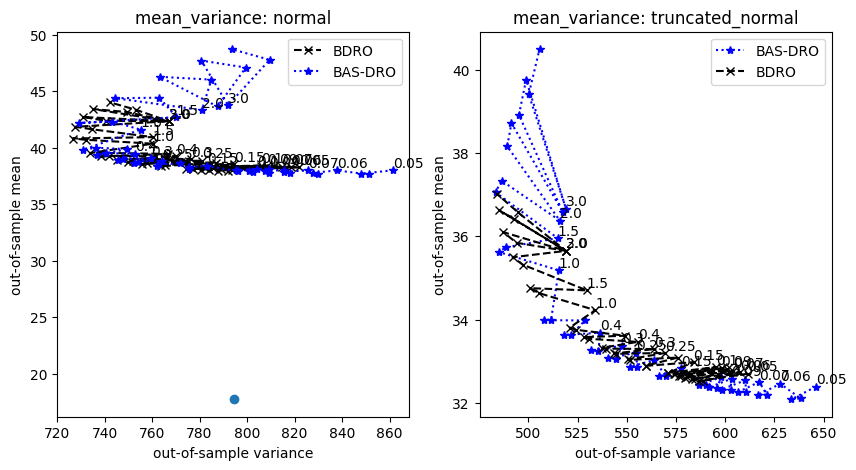

In [82]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
axes[0].scatter(mean_of_variances, var_of_means)
fig.show()

epsilon | mean squared error to opt | std of mean squared error
----------
0.1 | 